In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#21 вариант
a = 0.3
b = 11
N_task1 = 900
N_task2 = 1000
np.random.seed(42)

# Задание 1

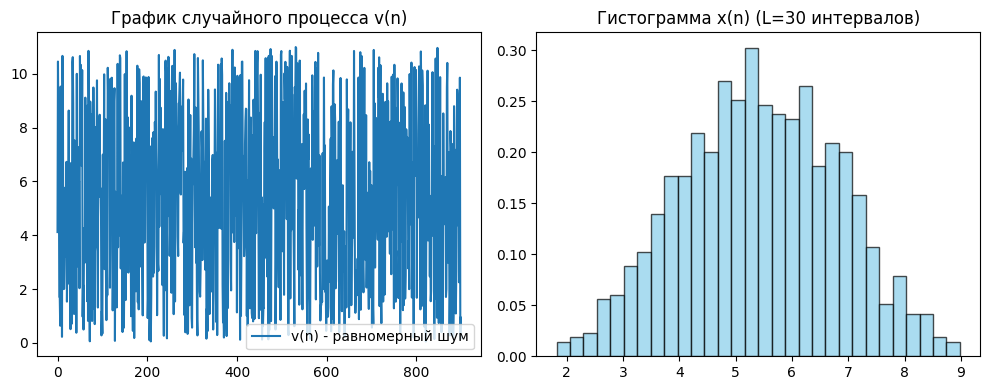

Оценка мат. ожидания mu_x* = 5.4232
Оценка дисперсии D_x* = 1.9247


In [3]:
# 1. Формирование v(n)
v = np.random.uniform(0, b, N_task1)

# 2. Фильтрация x(n)
x = np.zeros(N_task1)
x[0] = b / 2
for n in range(1, N_task1):
    x[n] = (1 - a) * x[n-1] + a * v[n]

# 3. Гистограмма
L = int(np.sqrt(N_task1)) # L = 30
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(v, label='v(n) - равномерный шум')
plt.title('График случайного процесса v(n)')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(x, bins=L, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Гистограмма x(n) (L={L} интервалов)')
plt.tight_layout()
plt.show()

# 4 и 5. Мат. ожидание и Дисперсия
mu_x = np.mean(x)
D_x = np.var(x, ddof=1) # ddof=1 для несмещенной оценки (N-1)
print(f"Оценка мат. ожидания mu_x* = {mu_x:.4f}")
print(f"Оценка дисперсии D_x* = {D_x:.4f}")

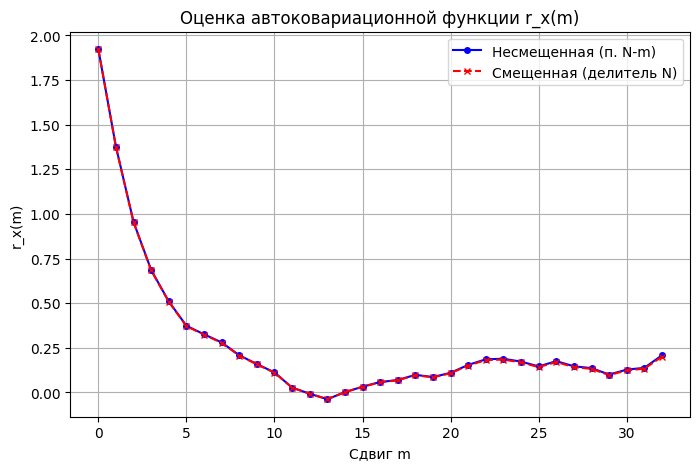

In [4]:
# 6. Автоковариационная функция (АКФ)
M = 32
r_unbiased = np.zeros(M + 1)
r_biased = np.zeros(M + 1)

for m in range(M + 1):
    # В методичке опечатка в верхнем пределе суммы (N-1-2), используем корректное (N-1-m)
    cov_sum = np.sum((x[:N_task1-m] - mu_x) * (x[m:] - mu_x))
    r_unbiased[m] = cov_sum / (N_task1 - m) # По рекомендации (несмещенная)
    r_biased[m] = cov_sum / N_task1         # "В противоположность" (смещенная)

plt.figure(figsize=(8, 5))
plt.plot(r_unbiased, 'b-o', markersize=4, label='Несмещенная (п. N-m)')
plt.plot(r_biased, 'r--x', markersize=4, label='Смещенная (делитель N)')
plt.title('Оценка автоковариационной функции r_x(m)')
plt.xlabel('Сдвиг m')
plt.ylabel('r_x(m)')
plt.legend()
plt.grid(True)
plt.show()

# Задание 2

Общие характеристики для N=1000: mu_x* = 5.5634, D_x* = 1.7354

Характеристики по блокам:
Блок 1: mu = 5.2057, D = 1.1916
Блок 2: mu = 5.8984, D = 2.2440
Блок 3: mu = 6.0561, D = 1.6981
Блок 4: mu = 5.1049, D = 1.7628
Блок 5: mu = 5.7225, D = 1.2740
Блок 6: mu = 5.6729, D = 1.8903
Блок 7: mu = 5.3813, D = 1.2650
Блок 8: mu = 5.6395, D = 2.0268
Блок 9: mu = 5.2009, D = 1.6953
Блок 10: mu = 5.7513, D = 1.5186


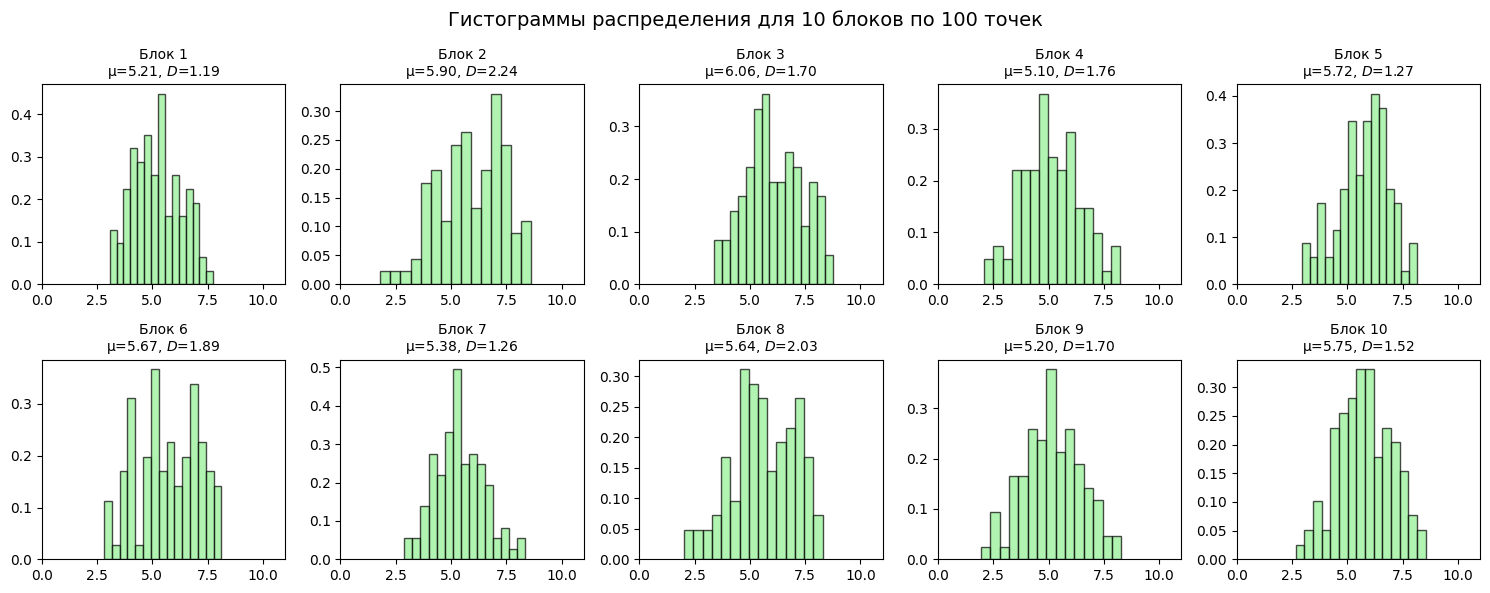

In [5]:
# 1. Массив N=1000
v2 = np.random.uniform(0, b, N_task2)
x2 = np.zeros(N_task2)
x2[0] = b / 2
for n in range(1, N_task2):
    x2[n] = (1 - a) * x2[n-1] + a * v2[n]

mu_total = np.mean(x2)
D_total = np.var(x2, ddof=1)
print(f"Общие характеристики для N=1000: mu_x* = {mu_total:.4f}, D_x* = {D_total:.4f}")

# 2, 3, 4. Разбиение на 10 блоков по 100 точек
num_blocks = 10
block_size = 100

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.flatten()

print("\nХарактеристики по блокам:")
for i in range(num_blocks):
    block = x2[i*block_size : (i+1)*block_size]
    mu_block = np.mean(block)
    D_block = np.var(block, ddof=1)
    print(f"Блок {i+1}: mu = {mu_block:.4f}, D = {D_block:.4f}")

    # Построение гистограмм
    axs[i].hist(block, bins=15, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
    axs[i].set_title(f'Блок {i+1}\nμ={mu_block:.2f}, $D$={D_block:.2f}', fontsize=10)
    axs[i].set_xlim(0, 11)

plt.suptitle('Гистограммы распределения для 10 блоков по 100 точек', fontsize=14)
plt.tight_layout()
plt.show()

# Сравнительный анализ


In [6]:
N = 1000
# 1. Генерация чистого сигнала
v = np.random.uniform(0, b, N)
x_clean = np.zeros(N)
x_clean[0] = b / 2
for n in range(1, N):
    x_clean[n] = (1 - a) * x_clean[n-1] + a * v[n]

# Внесение импульсной помехи
x_noisy = x_clean.copy()
x_noisy[500:521] *= 3

## Поиск помехи через скользящую дисперсию

In [7]:
window_size = 10
sliding_var = np.zeros(N - window_size + 1)

for i in range(N - window_size + 1):
    # Несмещенная оценка дисперсии внутри окна
    sliding_var[i] = np.var(x_noisy[i:i+window_size], ddof=1)

max_var_idx = np.argmax(sliding_var)
print(f"Максимальная скользящая дисперсия обнаружена в окне с начальным индексом: {max_var_idx}")
print(f"   (Это указывает на регион помехи, так как окно захватывает резкий скачок амплитуды)")

Максимальная скользящая дисперсия обнаружена в окне с начальным индексом: 515
   (Это указывает на регион помехи, так как окно захватывает резкий скачок амплитуды)


## Замена значений найденного окна на медиану


In [8]:
median_val = np.median(x_noisy)
x_corrected = x_noisy.copy()
# Заменяем только найденное окно из 10 отсчётов по условию задания.
x_corrected[max_var_idx:max_var_idx + window_size] = median_val
print(f"Заменено окно {max_var_idx}–{max_var_idx + window_size - 1}; медиана = {median_val:.4f}")

Заменено окно 515–524; медиана = 5.5942


## Расчет и сравнение характеристик

In [9]:
def calc_stats(x):
    mu = np.mean(x)
    D = np.var(x, ddof=1) # Несмещенная оценка
    return mu, D

mu_clean, D_clean = calc_stats(x_clean)
mu_noisy, D_noisy = calc_stats(x_noisy)
mu_corr, D_corr = calc_stats(x_corrected)

print("Статистические характеристики:")
print(f"   Чистый сигнал:       μ* = {mu_clean:.4f},  D* = {D_clean:.4f}")
print(f"   Сигнал с помехой:    μ* = {mu_noisy:.4f},  D* = {D_noisy:.4f}")
print(f"   После замены медианой: μ* = {mu_corr:.4f},  D* = {D_corr:.4f}")

Статистические характеристики:
   Чистый сигнал:       μ* = 5.4728,  D* = 1.8028
   Сигнал с помехой:    μ* = 5.6645,  D* = 3.3564
   После замены медианой: μ* = 5.6319,  D* = 2.9750


## Построение графиков для отчета

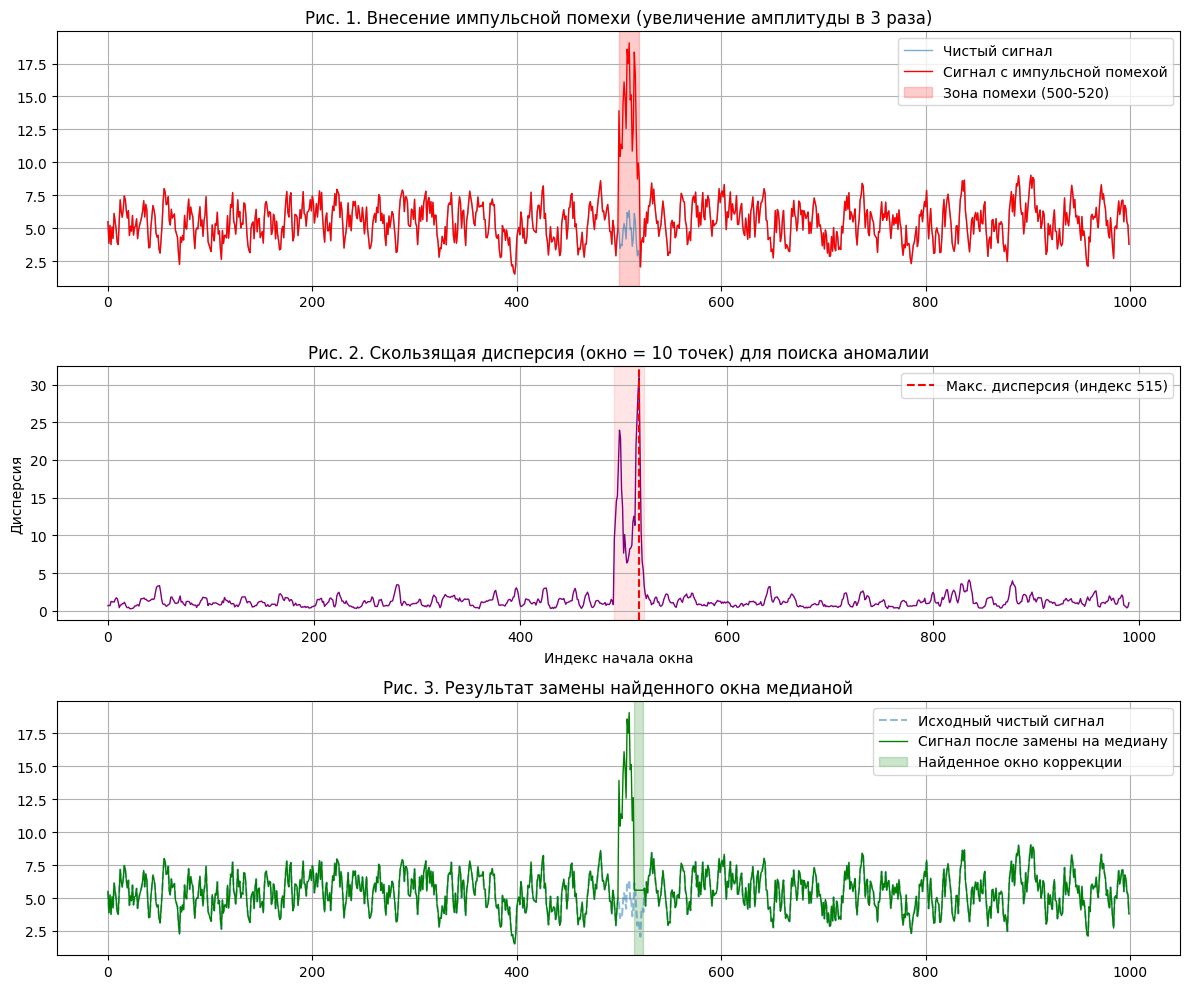

In [10]:
plt.figure(figsize=(12, 10))

# График 1: Сигнал до и после внесения помехи
plt.subplot(3, 1, 1)
plt.plot(x_clean, label='Чистый сигнал', alpha=0.6, linewidth=1)
plt.plot(x_noisy, label='Сигнал с импульсной помехой', color='red', linewidth=1)
plt.axvspan(500, 520, color='red', alpha=0.2, label='Зона помехи (500-520)')
plt.title('Рис. 1. Внесение импульсной помехи (увеличение амплитуды в 3 раза)')
plt.legend(loc='upper right')
plt.grid(True)

# График 2: Скользящая дисперсия
plt.subplot(3, 1, 2)
plt.plot(sliding_var, color='purple', linewidth=1)
plt.axvline(max_var_idx, color='red', linestyle='--', label=f'Макс. дисперсия (индекс {max_var_idx})')
plt.axvspan(500 - window_size + 1, 520, color='red', alpha=0.1) # Окна, пересекающие помеху
plt.title('Рис. 2. Скользящая дисперсия (окно = 10 точек) для поиска аномалии')
plt.xlabel('Индекс начала окна')
plt.ylabel('Дисперсия')
plt.legend()
plt.grid(True)

# График 3: Результат фильтрации
plt.subplot(3, 1, 3)
plt.plot(x_clean, label='Исходный чистый сигнал', alpha=0.5, linestyle='--')
plt.plot(x_corrected, label='Сигнал после замены на медиану', color='green', linewidth=1)
plt.axvspan(max_var_idx, max_var_idx + window_size - 1,
            color='green', alpha=0.2, label='Найденное окно коррекции')
plt.title('Рис. 3. Результат замены найденного окна медианой')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()